**House Price Prediction**


In [1]:
#Importing Libraries
%pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv("House price.csv")

In [5]:
#Dataset Shape
df.shape

(2000, 16)

In [6]:
#Dataset First 5 Rows
df.head()
#Dataset Information
df.info()
#Checking for Null Values
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Area              2000 non-null   int64
 1   Bedrooms          2000 non-null   int64
 2   Bathrooms         2000 non-null   int64
 3   Stories           2000 non-null   int64
 4   Parking           2000 non-null   int64
 5   Age               2000 non-null   int64
 6   City              2000 non-null   str  
 7   Furnishing        2000 non-null   str  
 8   Main Road         2000 non-null   str  
 9   Guest Room        2000 non-null   str  
 10  Basement          2000 non-null   str  
 11  Water Supply      2000 non-null   str  
 12  Air Conditioning  2000 non-null   str  
 13  Preferred Tenant  2000 non-null   str  
 14  Locality Rating   2000 non-null   int64
 15  Price             2000 non-null   int64
dtypes: int64(8), str(8)
memory usage: 250.1 KB


Area                0
Bedrooms            0
Bathrooms           0
Stories             0
Parking             0
Age                 0
City                0
Furnishing          0
Main Road           0
Guest Room          0
Basement            0
Water Supply        0
Air Conditioning    0
Preferred Tenant    0
Locality Rating     0
Price               0
dtype: int64

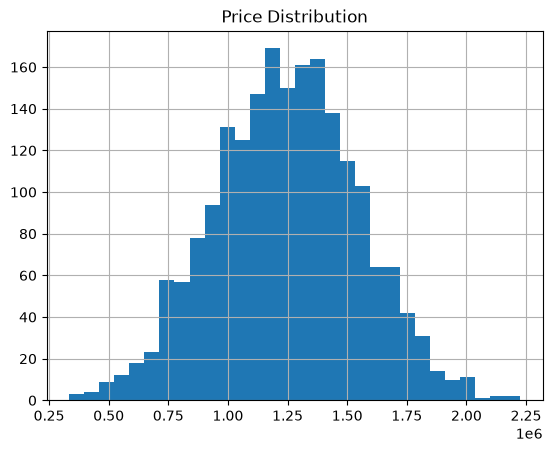

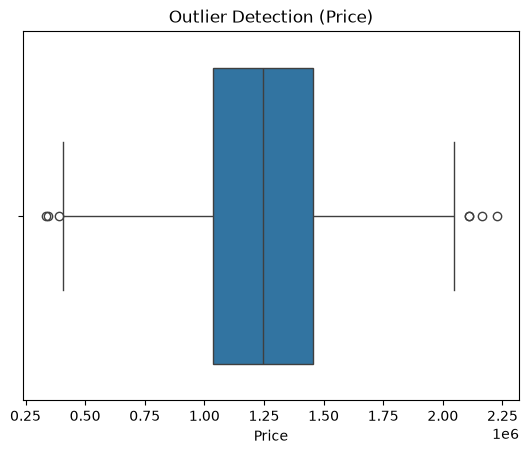

In [7]:
#Spotting Outliers

# Numeric distributions
df["Price"].hist(bins=30)
plt.title("Price Distribution")
plt.show()

# Boxplot for outliers
sns.boxplot(x=df["Price"])
plt.title("Outlier Detection (Price)")
plt.show()


**Data Preprocessing**

In [8]:
#Normalizing Numerical Data
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
# Select numeric features
numeric_features = ["Area","Bathrooms","Bedrooms",]
X_numeric = df[numeric_features].copy()
# Impute missing values (median)
num_imputer = SimpleImputer(strategy="median")
X_numeric_imputed = num_imputer.fit_transform(X_numeric)
# Apply Min-Max Scaling
scaler = MinMaxScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric_imputed)
# Convert back to DataFrame
X_numeric_scaled_df = pd.DataFrame(X_numeric_scaled, columns=numeric_features)
print(X_numeric_scaled_df.head())

       Area  Bathrooms  Bedrooms
0  0.153530        1.0      0.75
1  0.963181        0.0      0.25
2  0.933870        0.5      1.00
3  0.927614        0.0      0.00
4  0.673995        0.0      1.00


In [9]:
#Encoding Categorical Data
from sklearn.preprocessing import OneHotEncoder

# Select categorical feature
categorical_feature = ["City"]
X_categorical = df[categorical_feature].copy()

# Impute missing values (most frequent)
cat_imputer = SimpleImputer(strategy="most_frequent")
X_categorical_imputed = cat_imputer.fit_transform(X_categorical)

# Apply One-Hot Encoding
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_encoded = encoder.fit_transform(X_categorical_imputed)

# Get column names from encoder
encoded_columns = encoder.get_feature_names_out(categorical_feature)

# Convert back to DataFrame
X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_columns)
print(X_encoded_df.head())

   City_Bangalore  City_Chennai  City_Delhi  City_Hyderabad  City_Kolkata  \
0             0.0           0.0         0.0             0.0           0.0   
1             0.0           0.0         0.0             0.0           1.0   
2             0.0           1.0         0.0             0.0           0.0   
3             0.0           0.0         1.0             0.0           0.0   
4             0.0           0.0         1.0             0.0           0.0   

   City_Mumbai  City_Pune  
0          0.0        1.0  
1          0.0        0.0  
2          0.0        0.0  
3          0.0        0.0  
4          0.0        0.0  


**Feature Selection**

In [10]:
correlations = df.corr(numeric_only=True)["Price"].sort_values(ascending=False)
print("Correlation with Price:")
print(correlations)

Correlation with Price:
Price              1.000000
Bedrooms           0.600588
Area               0.339137
Bathrooms          0.267506
Locality Rating    0.205792
Stories            0.205615
Parking            0.159216
Age               -0.056614
Name: Price, dtype: float64


**Model Training**

In [11]:
from sklearn.model_selection import train_test_split

X = df[numeric_features + categorical_feature]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
#Linear Regression Model
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Define preprocessing for numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", num_imputer),
            ("scaler", scaler)
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", cat_imputer),
            ("encoder", encoder)
        ]), categorical_feature)
    ]
)

model = Pipeline([
    ("preprocessing", preprocessor),
    ("regression", LinearRegression())
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['Area','Bathrooms','Bedrooms','City']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the outp

**Model Evaluation**

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

RMSE: 189574.92
R² Score: 0.6035
